In [13]:
# This cell does not render in the docs because it has a `nbsphinx: hidden` tag.
import warnings

warnings.filterwarnings("ignore")

# Quickstart

Glass Box UMAP works like standard parametric UMAP but adds the ability to compute exact feature contributions to the embedding.

## Basic Usage

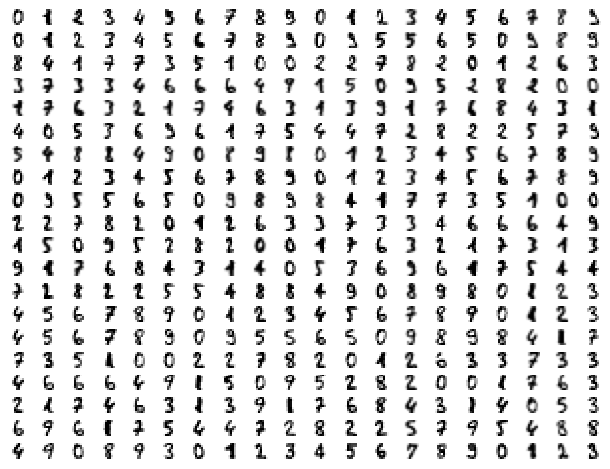

In [14]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

fig, ax_array = plt.subplots(20, 20)
axes = ax_array.flatten()
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray_r')
plt.setp(axes, xticks=[], yticks=[], frame_on=False)
plt.tight_layout(h_pad=0.5, w_pad=0.01)

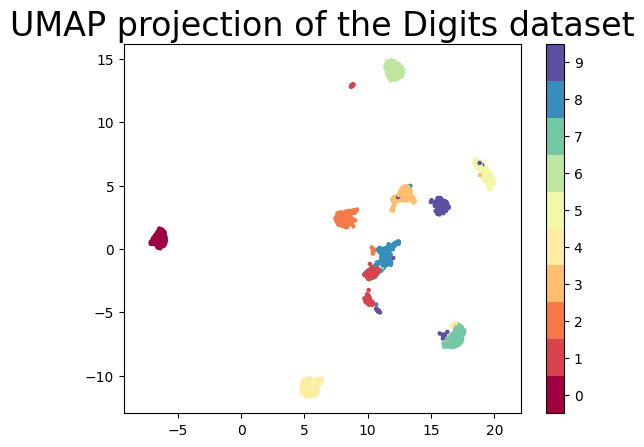

In [15]:
import numpy as np
from umap import UMAP

reducer = UMAP(random_state=42)
reducer.fit(digits.data)

umap_embedding = reducer.transform(digits.data)

plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=digits.target, cmap='Spectral', s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP projection of the Digits dataset', fontsize=24);

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Thu Feb 12 14:10:15 2026 Building RP forest with 7 trees
Thu Feb 12 14:10:15 2026 NN descent for 11 iterations
	 1  /  11
	 2  /  11
	 3  /  11
	 4  /  11
	Stopping threshold met -- exiting after 4 iterations


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ DeepPReLUNet │  280 K │ train │     0 │
└───┴─────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 280 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 280 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=500` reached.


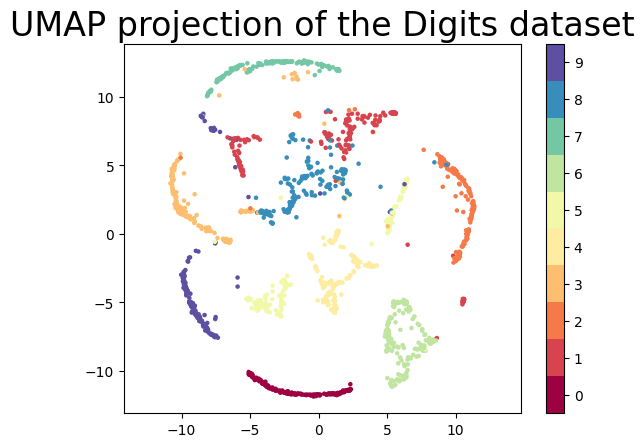

In [16]:
import torch
from glass_box_umap import GlassBoxUMAP

digits_tensor = torch.from_numpy(digits.data)
reducer = GlassBoxUMAP(random_state=42, epochs=500)
reducer.fit(digits_tensor)

glass_box_umap_embedding = reducer.transform(digits_tensor)

plt.scatter(glass_box_umap_embedding[:, 0], glass_box_umap_embedding[:, 1], c=digits.target, cmap='Spectral', s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP projection of the Digits dataset', fontsize=24);

## Computing Feature Contributions

The main feature of Glass Box UMAP is computing exact contributions that explain how each input feature contributes to the embedding coordinates:

In [2]:
contributions, jacobians = model.compute_contributions(X)

print(f"contributions shape: {contributions.shape}")
print("contributions[i, j, k] = contribution of feature k to embedding dimension j for sample i")

contributions shape: (1000, 2, 50)
contributions[i, j, k] = contribution of feature k to embedding dimension j for sample i


Each sample's embedding can be reconstructed exactly by summing its feature contributions:

In [3]:
import numpy as np

reconstructed = contributions.sum(axis=2)
print(f"Reconstruction matches embedding: {np.allclose(reconstructed, embedding, atol=1e-5)}")

Reconstruction matches embedding: False


## Interpreting Contributions

Feature contributions tell you which features are responsible for a point's position in the embedding:

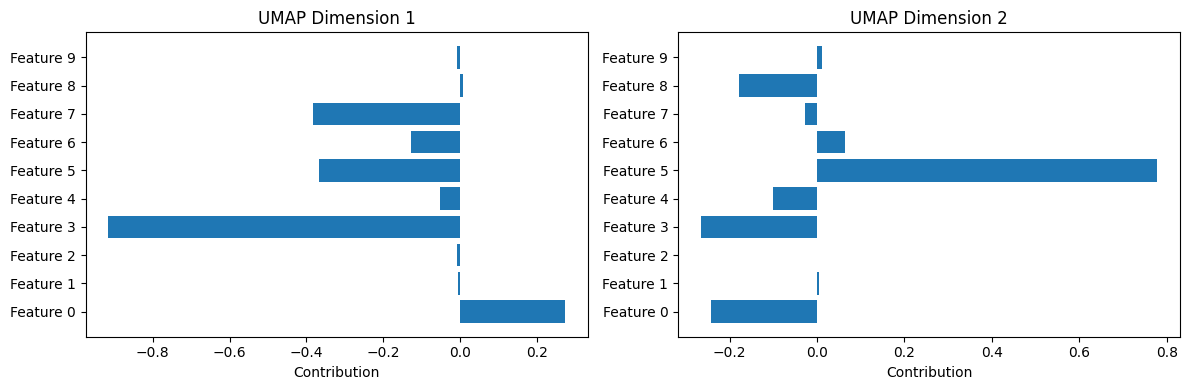

In [4]:
import matplotlib.pyplot as plt

sample_idx = 0
feature_names = [f"Feature {i}" for i in range(X.shape[1])]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for dim in range(2):
    ax = axes[dim]
    contrib = contributions[sample_idx, dim, :]
    ax.barh(feature_names[:10], contrib[:10])
    ax.set_xlabel("Contribution")
    ax.set_title(f"UMAP Dimension {dim + 1}")
plt.tight_layout()

## Using PCA Preprocessing

For high-dimensional data, you can apply PCA before the UMAP encoder. Contributions are automatically projected back to the original feature space:

In [ ]:
model_pca = GlassBoxUMAP(
    n_neighbors=15,
    min_dist=0.1,
    pca_components=30,
    epochs=50,
)
embedding_pca = model_pca.fit_transform(X)

contributions_pca, _ = model_pca.compute_contributions(X)
print(f"Contributions shape: {contributions_pca.shape}")
print(f"Original feature count: {X.shape[1]}")

## Saving and Loading Models

In [ ]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmpdir:
    path = Path(tmpdir) / "glass_box_umap_model.pt"
    model.save(path)
    loaded_model = GlassBoxUMAP.load(path)
    print(f"Model saved and loaded from {path}")